# Is Hier-COS inference itself the main advantage?

This notebook performs an inference-only, paired comparison on existing checkpoints. No model is retrained.

- **H-CAST and HRN:** native inference versus post-hoc identity-frame Hier-COS distance inference.
- **Hier-COS:** native distance inference versus direct global node-softmax inference.

The key quantity is the within-checkpoint **distance gain**. Positive always means that distance inference is better, including for lower-is-better AHD and TICE. Absolute cross-model scores are secondary because architectures and training objectives differ. Every completed seed is evaluated separately; its YAML stays in that seed's run directory, and tables/plots report mean ± sample standard deviation with the seed count.

Each figure gives every metric its own scale. The left column connects the reference and distance-inference means; the right column shows the direction-adjusted paired gain, individual seed gains, and a zero line. This keeps percentage-point metrics separate from raw AHD units and makes one-seed comparisons explicit.

## Experimental cautions

1. H-CAST/HRN logits were not trained as Hier-COS coordinates; identity-frame decoding is a post-hoc assumption.
2. The available best checkpoints were selected using each model's native validation inference. This can favor native inference.
3. Top-down and independent rows must use their corresponding best checkpoints. This notebook preserves that rule.
4. Unequal seed coverage must be reported. A one-seed sign is suggestive, not robust evidence.
5. Treat this test-set analysis as a pre-specified ablation. Do not tune normalization or score variants repeatedly on test data.

In [13]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import torch
import yaml

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'evaluation').is_dir():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'evaluation').is_dir(), 'Run this notebook from the repository or notebooks directory.'

NOTEBOOK_UTILS = str(REPO_ROOT / 'notebooks')
if NOTEBOOK_UTILS not in sys.path:
    sys.path.insert(0, NOTEBOOK_UTILS)
from multiseed_utils import discover_seed_dirs, sample_stats

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
DATASETS = ('cifar100', 'cub200', 'aircraft')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cpu':
    print('CUDA is unavailable; inference will run on CPU and may be slow.')
RUN_EVALUATION = True  # The next execution cell runs the Python checkpoint evaluator.
OVERWRITE = False

BASELINE_ROOTS = {
    'cifar100': {
        'hcast': OUTPUTS_ROOT / 'hcast_cifar100',
        #'hrn': OUTPUTS_ROOT / 'hrn_cifar100',
        'hiercos': OUTPUTS_ROOT / 'hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf',
    },
    'cub200': {
        'hcast': OUTPUTS_ROOT / 'hcast_cub200',
        #'hrn': OUTPUTS_ROOT / 'hrn_cub200',
        'hiercos': OUTPUTS_ROOT / 'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf',
    },
    'aircraft': {
        'hcast': OUTPUTS_ROOT / 'hcast_aircraft',
        #'hrn': OUTPUTS_ROOT / 'hrn_aircraft',
        'hiercos': OUTPUTS_ROOT / 'hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf',
    },
}

BASELINE_ROOTS

{'cifar100': {'hcast': PosixPath('/scratch/g.saggini1/outputs/hcast_cifar100'),
  'hiercos': PosixPath('/scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf')},
 'cub200': {'hcast': PosixPath('/scratch/g.saggini1/outputs/hcast_cub200'),
  'hiercos': PosixPath('/scratch/g.saggini1/outputs/hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf')},
 'aircraft': {'hcast': PosixPath('/scratch/g.saggini1/outputs/hcast_aircraft'),
  'hiercos': PosixPath('/scratch/g.saggini1/outputs/hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf')}}

In [14]:
def completed_seed_dirs(root: Path):
    seed_dirs = discover_seed_dirs(root, require_log=False, require_config=True)
    candidates = seed_dirs or ([root] if root.is_dir() else [])
    required = ('config_resolved.yaml', 'best_topdown.pt', 'best_independent.pt')
    return [path for path in candidates if all((path / name).is_file() for name in required)]

run_dirs = {
    dataset: {model: completed_seed_dirs(root) for model, root in BASELINE_ROOTS[dataset].items()}
    for dataset in DATASETS
}
coverage = pd.DataFrame(
    [
        {'dataset': dataset, 'model': model, 'runs': len(paths), 'paths': [str(path) for path in paths]}
        for dataset, model_runs in run_dirs.items()
        for model, paths in model_runs.items()
    ]
)
display(coverage)
missing_baselines = coverage.loc[coverage['runs'].eq(0), ['dataset', 'model']]
if not missing_baselines.empty:
    print('Missing completed baselines:')
    display(missing_baselines)
    print('Edit BASELINE_ROOTS or finish those runs before making a three-model claim.')

,dataset,model,runs,paths
0,cifar100,hcast,3,[/scratch/g.saggini1/outputs/hcast_cifar100/se...
1,cifar100,hiercos,3,[/scratch/g.saggini1/outputs/hiercos_cifar100_...
2,cub200,hcast,3,[/scratch/g.saggini1/outputs/hcast_cub200/seed...
3,cub200,hiercos,3,[/scratch/g.saggini1/outputs/hiercos_cub200_gl...
4,aircraft,hcast,3,[/scratch/g.saggini1/outputs/hcast_aircraft/se...
5,aircraft,hiercos,3,[/scratch/g.saggini1/outputs/hiercos_aircraft_...


In [15]:
result_files = []
for dataset, model_runs in run_dirs.items():
    for model, paths in model_runs.items():
        for run_dir in paths:
            output_path = run_dir / 'posthoc_inference_test_metrics.yaml'
            result_files.append(output_path)
            if not RUN_EVALUATION:
                continue
            if output_path.exists() and not OVERWRITE:
                print('[reuse]', output_path)
                continue
            command = [
                sys.executable, '-m', 'evaluation.evaluate_checkpoints',
                '--run-dir', str(run_dir),
                '--inference-mode', 'both',
                '--checkpoint-mode', 'both',
                '--device', DEVICE,
            ]
            if OVERWRITE:
                command.append('--overwrite')
            print('[run]', ' '.join(command))
            subprocess.run(command, cwd=REPO_ROOT, check=True)

available_result_files = [path for path in result_files if path.is_file()]
print(f'Available result files: {len(available_result_files)}/{len(result_files)}')
if not RUN_EVALUATION and not available_result_files:
    print('Set RUN_EVALUATION=True and run this cell to generate results.')

[reuse] /scratch/g.saggini1/outputs/hcast_cifar100/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cifar100/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cifar100/seed_2/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf/seed_2/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cub200/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cub200/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cub200/seed_2/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/h

In [16]:
records = []
for result_path in available_result_files:
    payload = yaml.safe_load(result_path.read_text())
    model = payload['model']
    seed = int(payload['seed'])
    for checkpoint_mode, checkpoint_payload in payload['checkpoints'].items():
        for inference_mode, metrics in checkpoint_payload['inference'].items():
            for metric, value in metrics.items():
                # Keep only the decoder matched to the validation-selected checkpoint.
                if metric.startswith(('fpa_', 'tice_', 'ahd_', 'weighted_ap_')) and not metric.endswith(checkpoint_mode):
                    continue
                if metric.startswith('acc_level_') and f'acc_level_{checkpoint_mode}_' not in metric:
                    continue
                records.append({
                    'dataset': payload['dataset'],
                    'model': model,
                    'seed': seed,
                    'checkpoint_mode': checkpoint_mode,
                    'inference': inference_mode,
                    'metric': metric,
                    'value': float(value),
                })

results_long = pd.DataFrame(records)
if results_long.empty:
    print('No result rows loaded yet.')
else:
    display(results_long.head())

,dataset,model,seed,checkpoint_mode,inference,metric,value
0,cifar-100,hcast,0,topdown,normal,ahd_topdown,0.4869
1,cifar-100,hcast,0,topdown,normal,fpa_topdown,0.7519
2,cifar-100,hcast,0,topdown,normal,acc_level_topdown_0,0.9092
3,cifar-100,hcast,0,topdown,normal,acc_level_topdown_1,0.8520
4,cifar-100,hcast,0,topdown,normal,acc_level_topdown_2,0.7519


In [17]:
DISTANCE_MODE = {'hcast': 'hiercos', 'hrn': 'hiercos', 'hiercos': 'normal'}
REFERENCE_MODE = {'hcast': 'normal', 'hrn': 'normal', 'hiercos': 'node_softmax'}
LOWER_IS_BETTER_PREFIXES = ('ahd_', 'tice_')

paired_rows = []
if not results_long.empty:
    index_cols = ['dataset', 'model', 'seed', 'checkpoint_mode', 'metric']
    wide = results_long.pivot_table(index=index_cols, columns='inference', values='value', aggfunc='first').reset_index()
    for row in wide.to_dict('records'):
        distance_mode = DISTANCE_MODE[row['model']]
        reference_mode = REFERENCE_MODE[row['model']]
        if distance_mode not in row or reference_mode not in row:
            continue
        distance_value = row[distance_mode]
        reference_value = row[reference_mode]
        if pd.isna(distance_value) or pd.isna(reference_value):
            continue
        lower_is_better = row['metric'].startswith(LOWER_IS_BETTER_PREFIXES)
        gain = reference_value - distance_value if lower_is_better else distance_value - reference_value
        paired_rows.append({
            **{key: row[key] for key in index_cols},
            'distance_inference': distance_mode,
            'reference_inference': reference_mode,
            'distance_value': distance_value,
            'reference_value': reference_value,
            'distance_gain': gain,
        })

paired = pd.DataFrame(paired_rows)
if paired.empty:
    print('No paired comparisons available.')
else:
    paired['distance_gain_display'] = paired.apply(
        lambda row: row['distance_gain'] if row['metric'].startswith('ahd_') else 100.0 * row['distance_gain'],
        axis=1,
    )
    display(paired.sort_values(['checkpoint_mode', 'metric', 'model', 'seed']))

,dataset,model,seed,checkpoint_mode,metric,distance_inference,reference_inference,distance_value,reference_value,distance_gain,distance_gain_display
0,cifar-100,hcast,0,independent,acc_level_independent_0,hiercos,normal,0.907800,0.909200,-0.001400,-0.140000
84,cub-200-2011,hcast,0,independent,acc_level_independent_0,hiercos,normal,0.681912,0.983776,-0.301864,-30.186400
168,fgvc-aircraft,hcast,0,independent,acc_level_independent_0,hiercos,normal,0.930393,0.933093,-0.002700,-0.270027
14,cifar-100,hcast,1,independent,acc_level_independent_0,hiercos,normal,0.908700,0.910800,-0.002100,-0.210000
98,cub-200-2011,hcast,1,independent,acc_level_independent_0,hiercos,normal,0.678115,0.986538,-0.308423,-30.842251
...,...,...,...,...,...,...,...,...,...,...,...
153,cub-200-2011,hiercos,1,topdown,weighted_ap_topdown,normal,node_softmax,0.791018,0.789243,0.001775,0.177543
237,fgvc-aircraft,hiercos,1,topdown,weighted_ap_topdown,normal,node_softmax,0.855896,0.854890,0.001005,0.100510
83,cifar-100,hiercos,2,topdown,weighted_ap_topdown,normal,node_softmax,0.801009,0.801434,-0.000425,-0.042500
167,cub-200-2011,hiercos,2,topdown,weighted_ap_topdown,normal,node_softmax,0.798728,0.797940,0.000787,0.078732


Absolute inference results (mean, sample standard deviation, seed count):


,dataset,model,checkpoint_mode,inference,metric,mean_value,std_value,seeds
0,cifar-100,hcast,independent,hiercos,acc_level_independent_0,90.646667,0.312143,3
1,cifar-100,hcast,independent,hiercos,acc_level_independent_1,85.366667,0.300389,3
2,cifar-100,hcast,independent,hiercos,acc_level_independent_2,75.526667,0.083267,3
3,cifar-100,hcast,independent,hiercos,ahd_independent,0.516033,0.006389,3
4,cifar-100,hcast,independent,hiercos,fpa_independent,73.906667,0.015275,3
...,...,...,...,...,...,...,...,...
163,fgvc-aircraft,hiercos,topdown,normal,acc_level_topdown_2,81.738174,0.425719,3
164,fgvc-aircraft,hiercos,topdown,normal,ahd_topdown,0.377838,0.007006,3
165,fgvc-aircraft,hiercos,topdown,normal,fpa_topdown,81.738174,0.425719,3
166,fgvc-aircraft,hiercos,topdown,normal,tice_topdown,0.000000,0.000000,3


Paired distance-inference gains (mean, sample standard deviation, seed count):


,dataset,model,checkpoint_mode,metric,mean_distance_gain,std_distance_gain,seeds
0,cifar-100,hcast,independent,acc_level_independent_0,-0.173333,0.035119,3
1,cifar-100,hcast,independent,acc_level_independent_1,0.163333,0.094516,3
2,cifar-100,hcast,independent,acc_level_independent_2,-0.410000,0.147309,3
3,cifar-100,hcast,independent,ahd_independent,-0.005300,0.003292,3
4,cifar-100,hcast,independent,fpa_independent,0.430000,0.187350,3
...,...,...,...,...,...,...,...
79,fgvc-aircraft,hiercos,topdown,acc_level_topdown_2,0.080008,0.034644,3
80,fgvc-aircraft,hiercos,topdown,ahd_topdown,0.003000,0.001967,3
81,fgvc-aircraft,hiercos,topdown,fpa_topdown,0.080008,0.034644,3
82,fgvc-aircraft,hiercos,topdown,tice_topdown,0.000000,0.000000,3


[saved] /scratch/g.saggini1/outputs/analysis/posthoc_hiercos_inference_comparison/cifar_100_topdown_inference_comparison.png


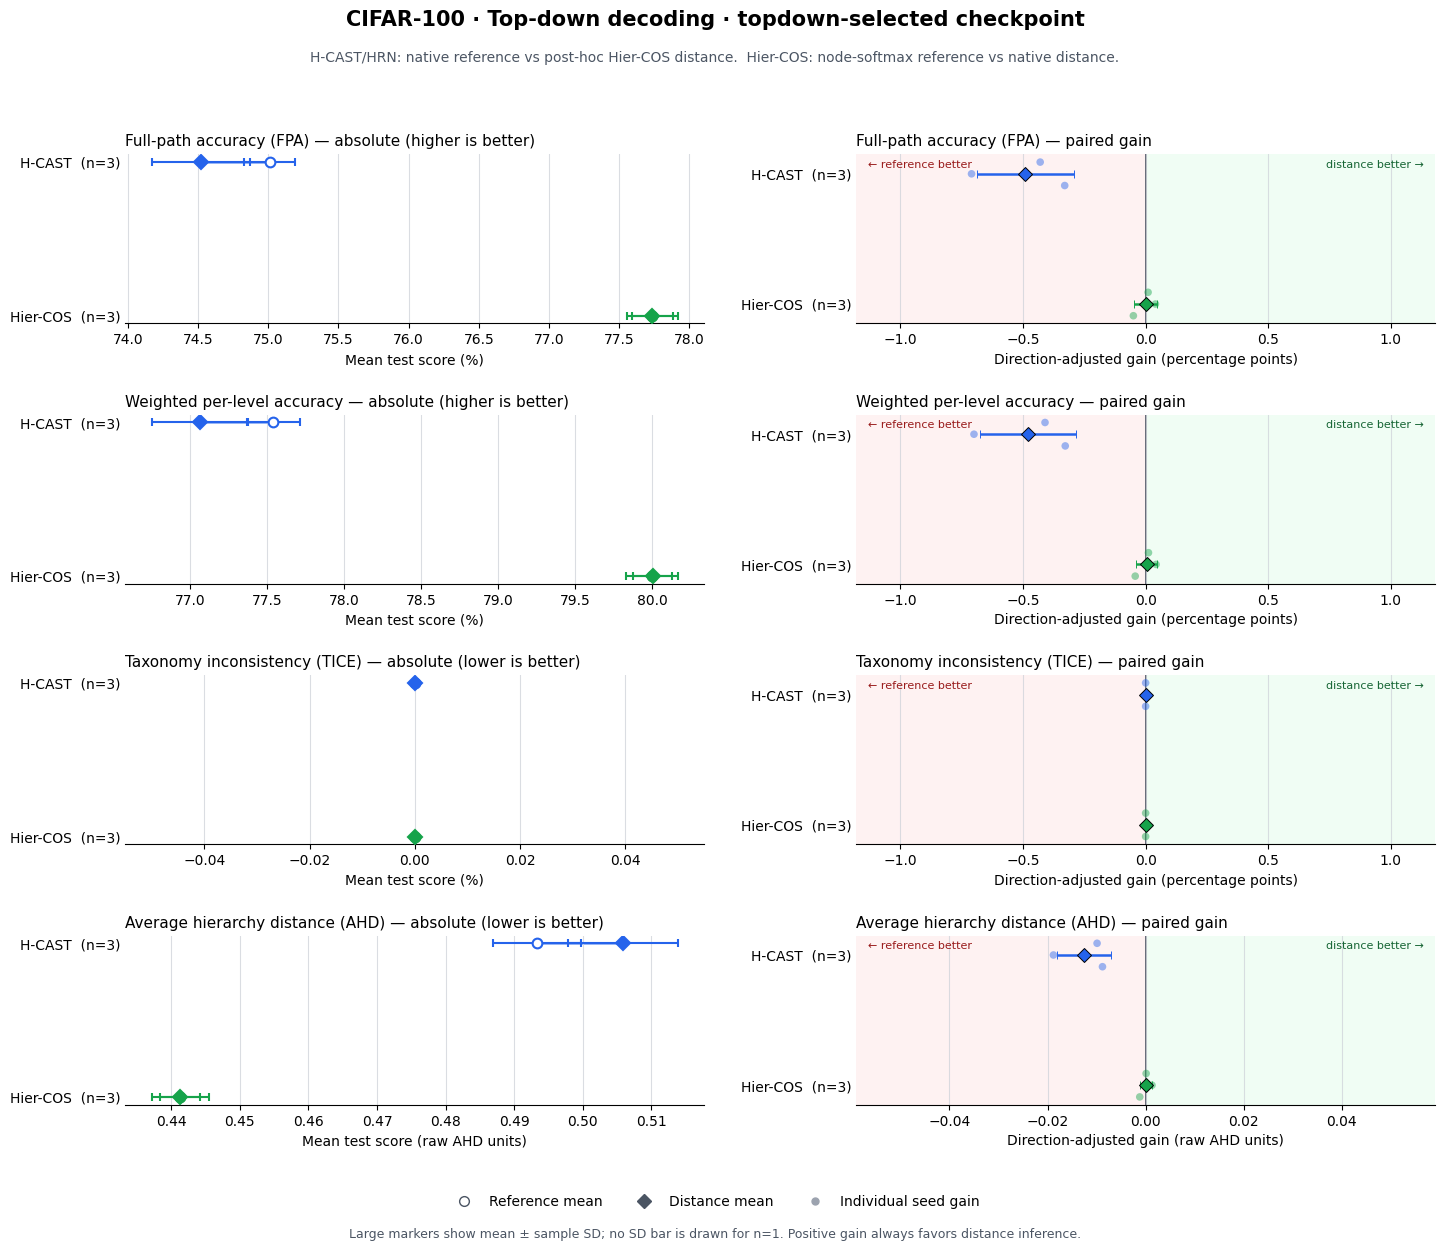

[saved] /scratch/g.saggini1/outputs/analysis/posthoc_hiercos_inference_comparison/cifar_100_independent_inference_comparison.png


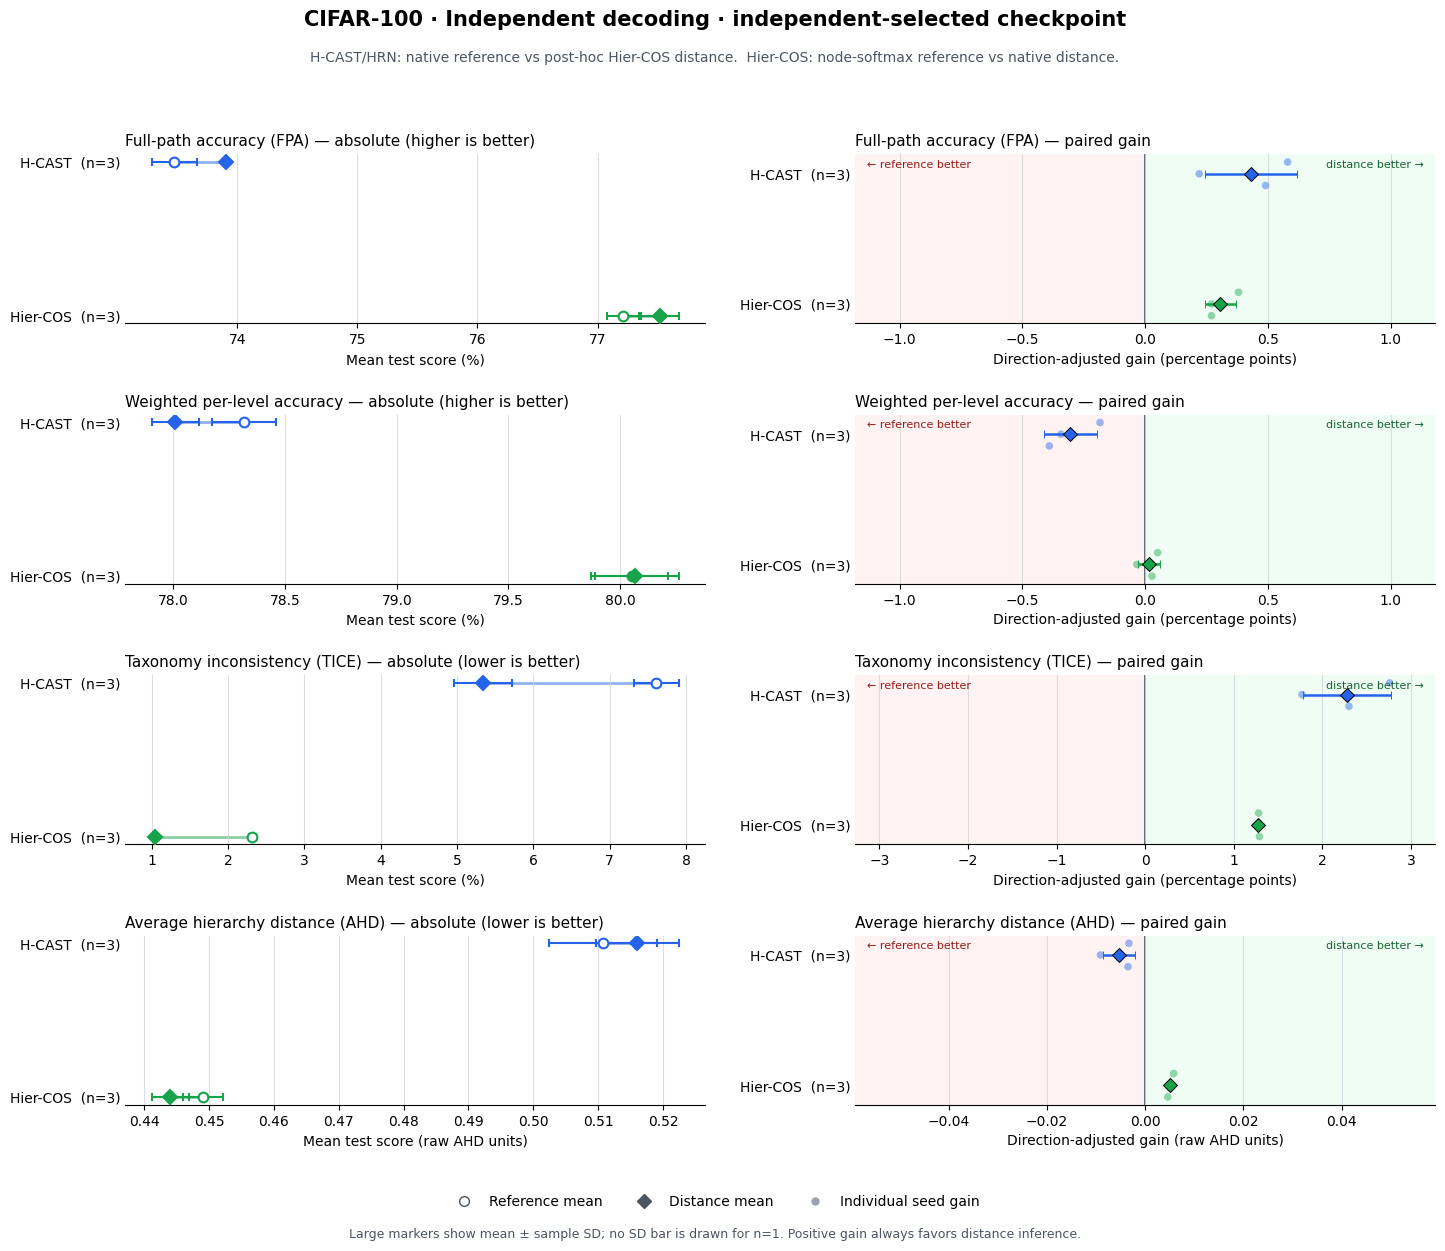

[saved] /scratch/g.saggini1/outputs/analysis/posthoc_hiercos_inference_comparison/cub_200_2011_topdown_inference_comparison.png


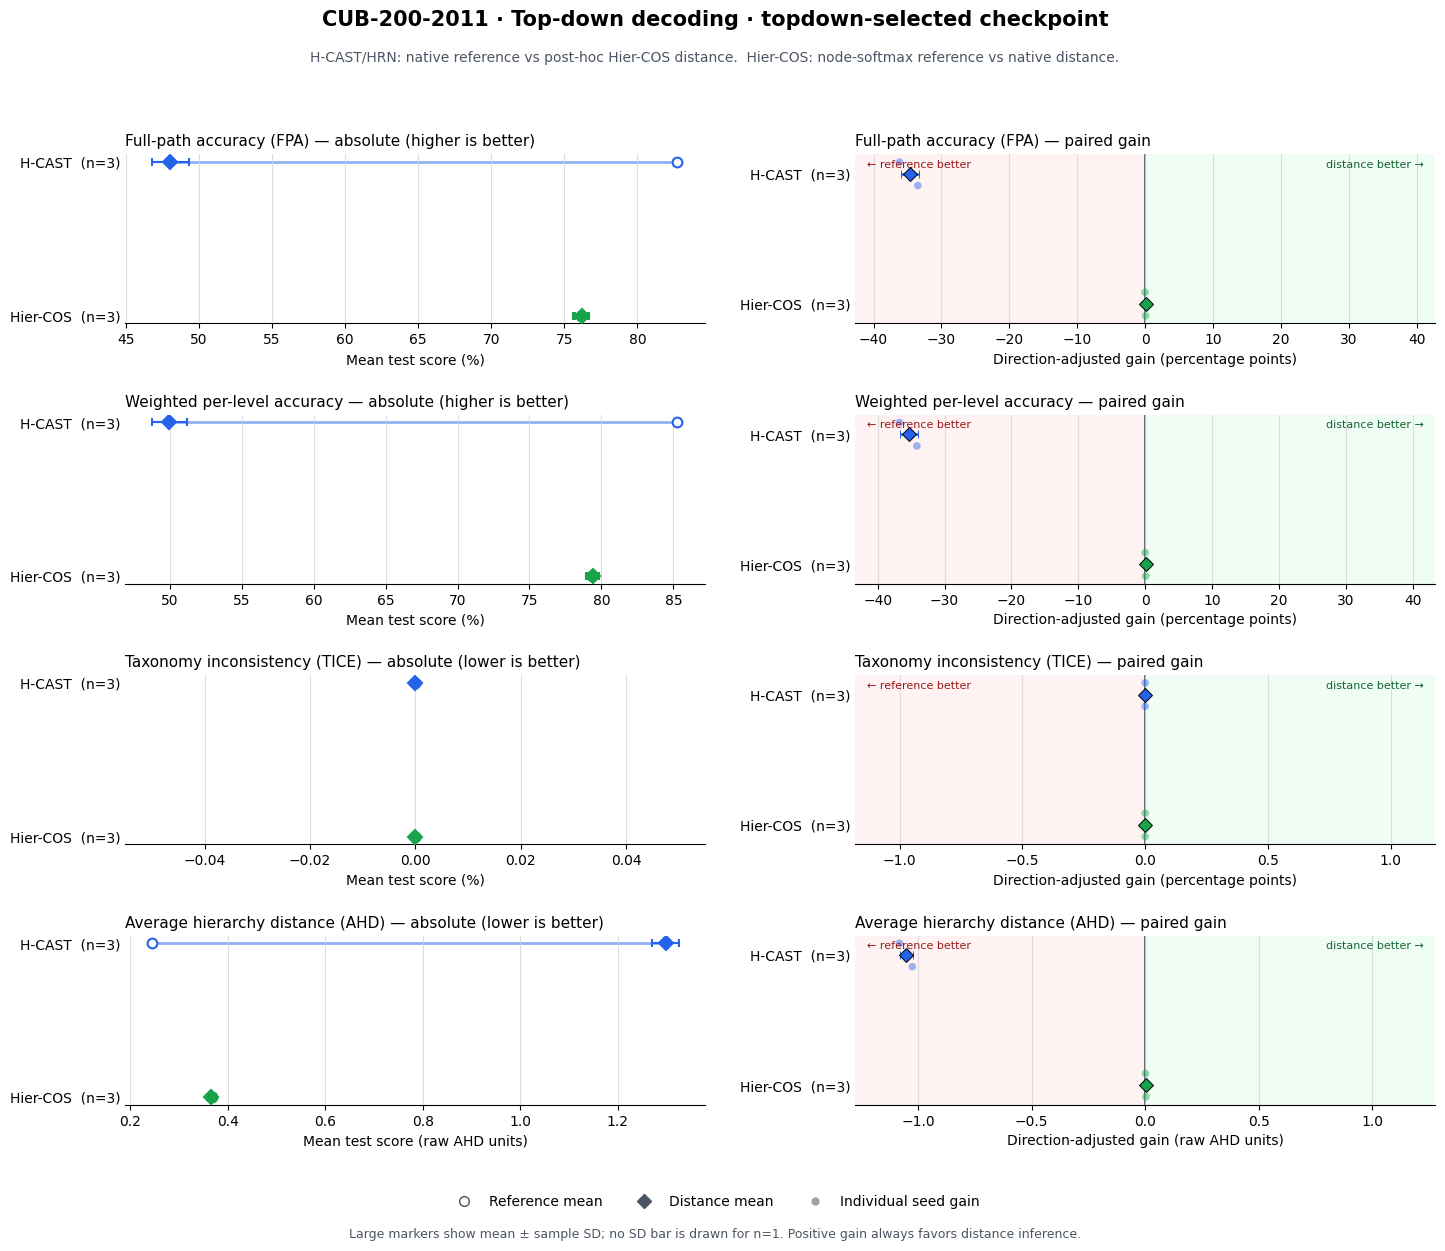

[saved] /scratch/g.saggini1/outputs/analysis/posthoc_hiercos_inference_comparison/cub_200_2011_independent_inference_comparison.png


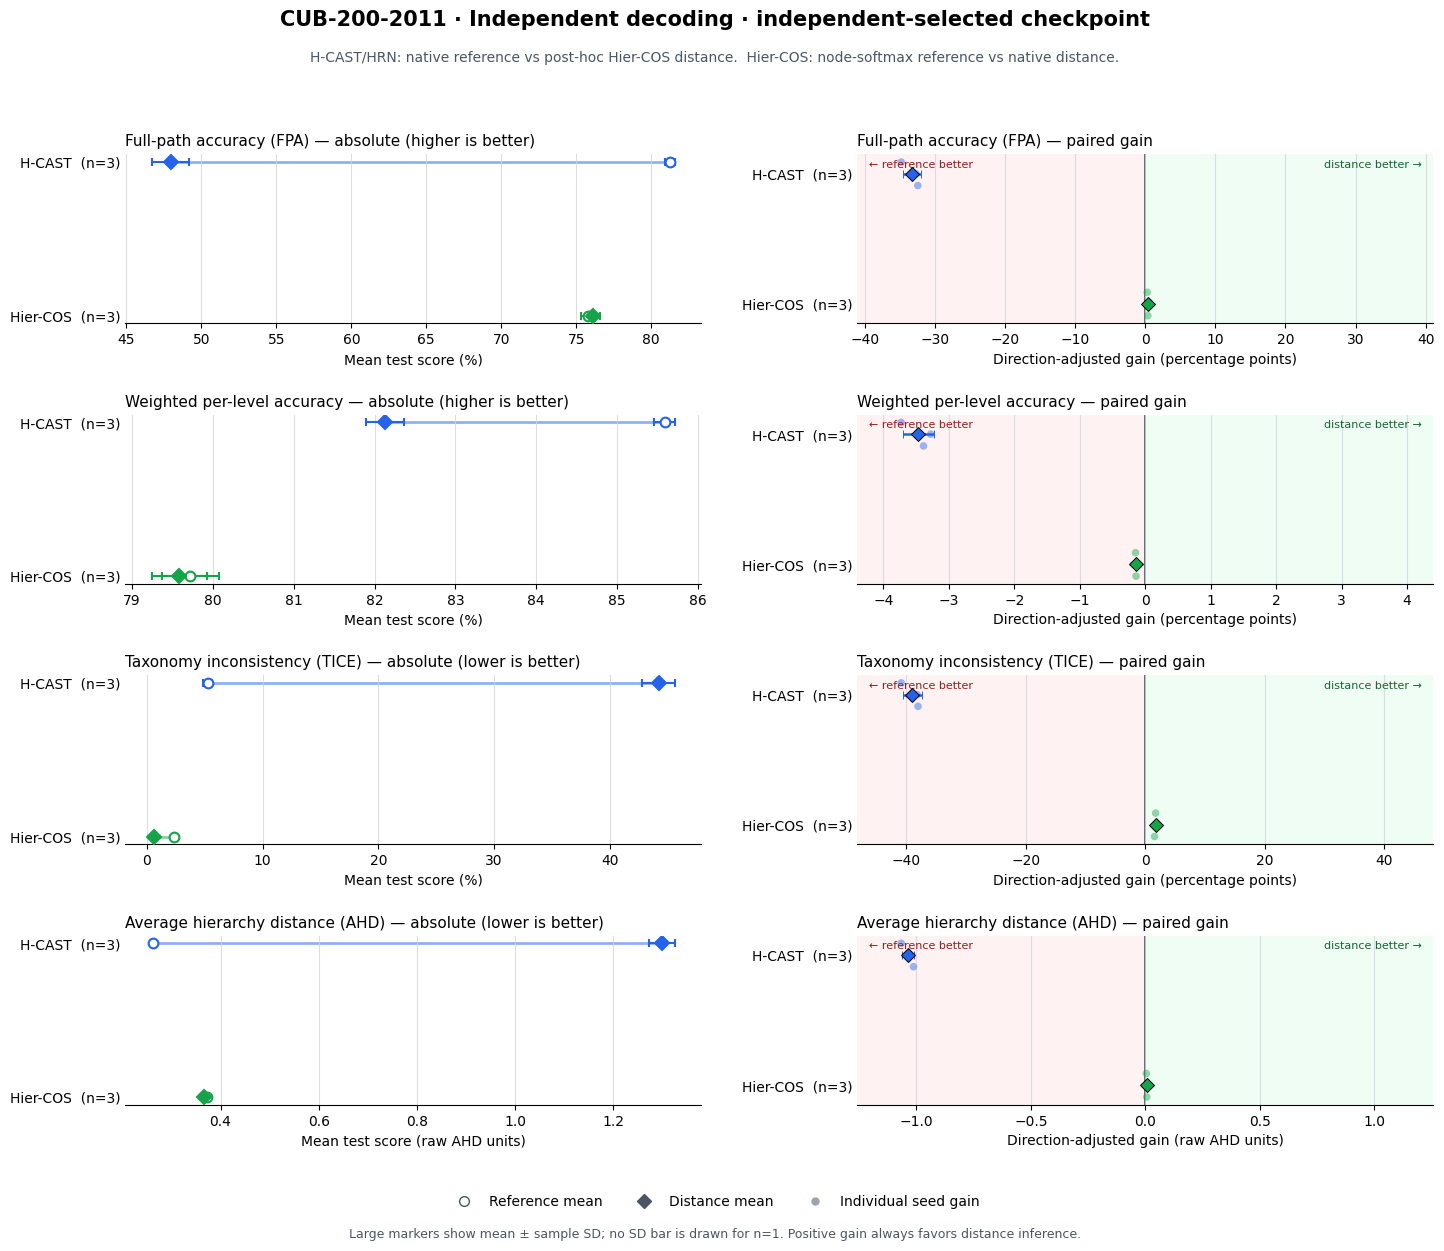

[saved] /scratch/g.saggini1/outputs/analysis/posthoc_hiercos_inference_comparison/fgvc_aircraft_topdown_inference_comparison.png


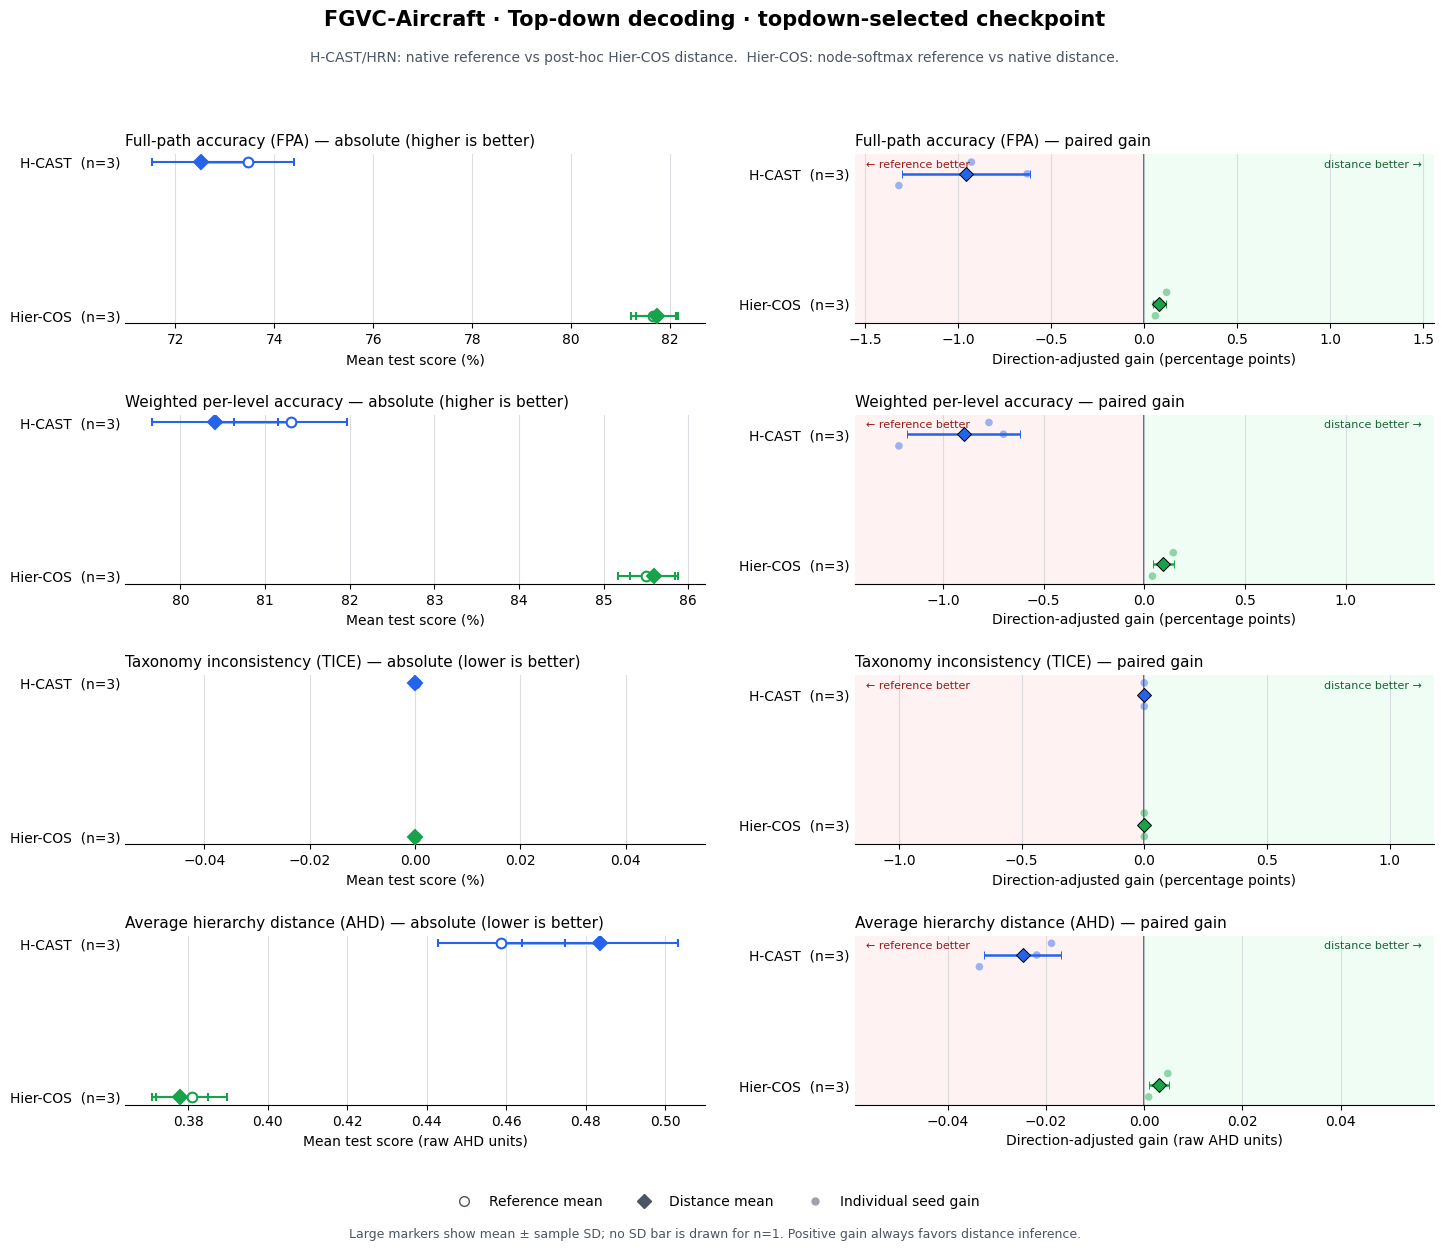

[saved] /scratch/g.saggini1/outputs/analysis/posthoc_hiercos_inference_comparison/fgvc_aircraft_independent_inference_comparison.png


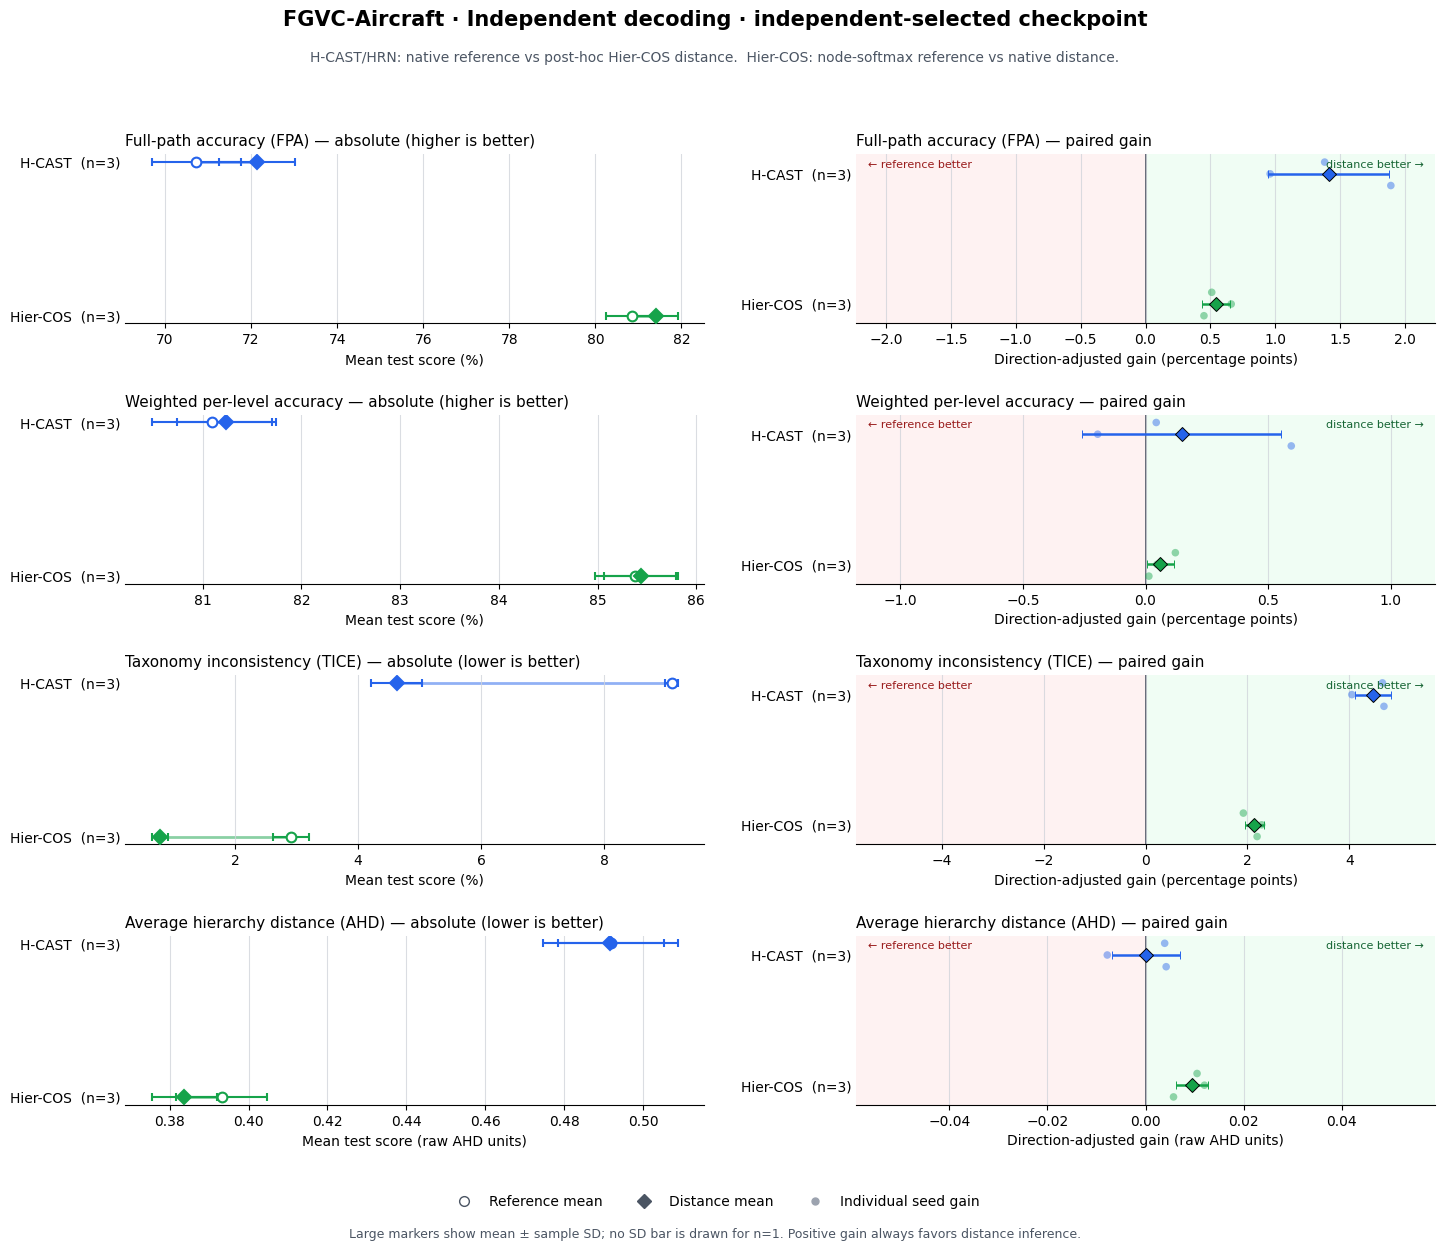

In [18]:
def summarize_samples(frame, group_columns, value_column, mean_column, std_column):
    rows = []
    for keys, group in frame.groupby(group_columns, dropna=False):
        keys = keys if isinstance(keys, tuple) else (keys,)
        mean, std, count = sample_stats(group[value_column].tolist())
        rows.append({
            **dict(zip(group_columns, keys)),
            mean_column: mean,
            std_column: std,
            'seeds': count,
        })
    return pd.DataFrame(rows)

if not results_long.empty:
    results_long['value_display'] = results_long.apply(
        lambda row: row['value'] if row['metric'].startswith('ahd_') else 100.0 * row['value'],
        axis=1,
    )
    absolute_summary = summarize_samples(
        results_long,
        ['dataset', 'model', 'checkpoint_mode', 'inference', 'metric'],
        'value_display',
        'mean_value',
        'std_value',
    )
    print('Absolute inference results (mean, sample standard deviation, seed count):')
    display(absolute_summary)

if not paired.empty:
    summary = summarize_samples(
        paired,
        ['dataset', 'model', 'checkpoint_mode', 'metric'],
        'distance_gain_display',
        'mean_distance_gain',
        'std_distance_gain',
    )
    print('Paired distance-inference gains (mean, sample standard deviation, seed count):')
    display(summary)

    MODEL_ORDER = ('hcast', 'hrn', 'hiercos')
    MODEL_LABELS = {'hcast': 'H-CAST', 'hrn': 'HRN', 'hiercos': 'Hier-COS'}
    MODEL_COLORS = {'hcast': '#2563eb', 'hrn': '#d97706', 'hiercos': '#16a34a'}
    DATASET_LABELS = {
        'cifar100': 'CIFAR-100', 'cifar-100': 'CIFAR-100',
        'cub200': 'CUB-200-2011', 'cub-200-2011': 'CUB-200-2011',
        'aircraft': 'FGVC-Aircraft', 'fgvc-aircraft': 'FGVC-Aircraft',
    }
    METRIC_SPECS = {
        'fpa': ('Full-path accuracy (FPA)', 'percentage points', True),
        'weighted_ap': ('Weighted per-level accuracy', 'percentage points', True),
        'tice': ('Taxonomy inconsistency (TICE)', 'percentage points', False),
        'ahd': ('Average hierarchy distance (AHD)', 'raw AHD units', False),
    }
    PLOT_OUTPUT_DIR = OUTPUTS_ROOT / 'analysis' / 'posthoc_hiercos_inference_comparison'
    SAVE_PLOTS = True

    def metric_family(metric):
        return next((name for name in METRIC_SPECS if metric.startswith(f'{name}_')), None)

    def finite_std(row, column):
        value = row[column]
        return float(value) if row['seeds'] > 1 and pd.notna(value) else None

    absolute_core = absolute_summary.copy()
    absolute_core['metric_family'] = absolute_core['metric'].map(metric_family)
    absolute_core = absolute_core[absolute_core['metric_family'].notna()]
    gain_core = summary.copy()
    gain_core['metric_family'] = gain_core['metric'].map(metric_family)
    gain_core = gain_core[gain_core['metric_family'].notna()]
    paired_core = paired.copy()
    paired_core['metric_family'] = paired_core['metric'].map(metric_family)
    paired_core = paired_core[paired_core['metric_family'].notna()]

    def plot_inference_comparison(dataset, checkpoint_mode):
        gain_slice = gain_core[
            gain_core['dataset'].eq(dataset) & gain_core['checkpoint_mode'].eq(checkpoint_mode)
        ]
        if gain_slice.empty:
            return

        present_metrics = [name for name in METRIC_SPECS if name in set(gain_slice['metric_family'])]
        fig, axes = plt.subplots(
            len(present_metrics), 2, figsize=(15, 3.1 * len(present_metrics)), squeeze=False
        )
        models = [model for model in MODEL_ORDER if model in set(gain_slice['model'])]
        y_positions = np.arange(len(models))

        for row_index, metric_name in enumerate(present_metrics):
            title, unit, higher_is_better = METRIC_SPECS[metric_name]
            absolute_ax, gain_ax = axes[row_index]
            metric_gains = gain_slice[gain_slice['metric_family'].eq(metric_name)]
            absolute_slice = absolute_core[
                absolute_core['dataset'].eq(dataset)
                & absolute_core['checkpoint_mode'].eq(checkpoint_mode)
                & absolute_core['metric_family'].eq(metric_name)
            ]

            tick_labels = []
            gain_extent = [0.0]
            for y_position, model in zip(y_positions, models):
                color = MODEL_COLORS[model]
                gain_rows = metric_gains[metric_gains['model'].eq(model)]
                seed_rows = paired_core[
                    paired_core['dataset'].eq(dataset)
                    & paired_core['checkpoint_mode'].eq(checkpoint_mode)
                    & paired_core['metric_family'].eq(metric_name)
                    & paired_core['model'].eq(model)
                ].sort_values('seed')
                seed_count = len(seed_rows)
                tick_labels.append(f'{MODEL_LABELS[model]}  (n={seed_count})')

                distance_mode = DISTANCE_MODE[model]
                reference_mode = REFERENCE_MODE[model]
                model_absolute = absolute_slice[absolute_slice['model'].eq(model)]
                distance_rows = model_absolute[model_absolute['inference'].eq(distance_mode)]
                reference_rows = model_absolute[model_absolute['inference'].eq(reference_mode)]
                if not distance_rows.empty and not reference_rows.empty:
                    distance_row = distance_rows.iloc[0]
                    reference_row = reference_rows.iloc[0]
                    distance_mean = distance_row['mean_value']
                    reference_mean = reference_row['mean_value']
                    absolute_ax.plot(
                        [reference_mean, distance_mean], [y_position, y_position],
                        color=color, linewidth=2, alpha=0.5, zorder=1,
                    )
                    for mean, row, marker, facecolor in (
                        (reference_mean, reference_row, 'o', 'white'),
                        (distance_mean, distance_row, 'D', color),
                    ):
                        xerr = finite_std(row, 'std_value')
                        absolute_ax.errorbar(
                            mean, y_position, xerr=xerr, fmt=marker, markersize=7,
                            color=color, markerfacecolor=facecolor, markeredgewidth=1.5,
                            capsize=3, linewidth=1.5, zorder=3,
                        )

                if not seed_rows.empty:
                    seed_values = seed_rows['distance_gain_display'].to_numpy()
                    offsets = np.linspace(-0.09, 0.09, seed_count) if seed_count > 1 else np.array([0.0])
                    gain_ax.scatter(
                        seed_values, y_position + offsets, s=30, color=color, alpha=0.45,
                        edgecolors='none', zorder=2,
                    )
                    gain_extent.extend(seed_values.tolist())
                if not gain_rows.empty:
                    gain_row = gain_rows.iloc[0]
                    gain_mean = gain_row['mean_distance_gain']
                    gain_std = finite_std(gain_row, 'std_distance_gain')
                    gain_ax.errorbar(
                        gain_mean, y_position, xerr=gain_std, fmt='D', markersize=7,
                        color=color, markeredgecolor='black', markeredgewidth=0.7,
                        capsize=3, linewidth=1.8, zorder=4,
                    )
                    gain_extent.append(float(gain_mean))
                    if gain_std is not None:
                        gain_extent.extend([gain_mean - gain_std, gain_mean + gain_std])

            for ax in (absolute_ax, gain_ax):
                ax.set_yticks(y_positions, tick_labels)
                ax.invert_yaxis()
                ax.grid(axis='x', color='#d1d5db', linewidth=0.8, alpha=0.8)
                ax.spines[['top', 'right', 'left']].set_visible(False)
                ax.tick_params(axis='y', length=0)

            direction = 'higher is better' if higher_is_better else 'lower is better'
            absolute_unit = '%' if unit == 'percentage points' else 'raw AHD units'
            absolute_ax.set_title(f'{title} — absolute ({direction})', loc='left', fontsize=11)
            absolute_ax.set_xlabel(f'Mean test score ({absolute_unit})')

            max_extent = max(abs(float(value)) for value in gain_extent if pd.notna(value))
            default_extent = 1.0 if unit == 'percentage points' else 0.05
            limit = 1.18 * max(max_extent, default_extent)
            gain_ax.set_xlim(-limit, limit)
            gain_ax.axvspan(-limit, 0, color='#fef2f2', zorder=0)
            gain_ax.axvspan(0, limit, color='#f0fdf4', zorder=0)
            gain_ax.axvline(0, color='#374151', linewidth=1.1, zorder=1)
            gain_ax.text(
                0.02, 0.97, '← reference better', transform=gain_ax.transAxes,
                ha='left', va='top', fontsize=8, color='#991b1b',
            )
            gain_ax.text(
                0.98, 0.97, 'distance better →', transform=gain_ax.transAxes,
                ha='right', va='top', fontsize=8, color='#166534',
            )
            gain_ax.set_title(f'{title} — paired gain', loc='left', fontsize=11)
            gain_ax.set_xlabel(f'Direction-adjusted gain ({unit})')

        dataset_label = DATASET_LABELS.get(dataset, dataset)
        decoder_label = 'Top-down' if checkpoint_mode == 'topdown' else 'Independent'
        fig.suptitle(
            f'{dataset_label} · {decoder_label} decoding · {checkpoint_mode}-selected checkpoint',
            fontsize=15, fontweight='bold', y=0.995,
        )
        fig.text(
            0.5, 0.962,
            'H-CAST/HRN: native reference vs post-hoc Hier-COS distance.  '
            'Hier-COS: node-softmax reference vs native distance.',
            ha='center', va='top', fontsize=10, color='#4b5563',
        )
        legend_handles = [
            Line2D([0], [0], marker='o', color='#4b5563', markerfacecolor='white',
                   linewidth=0, markersize=7, label='Reference mean'),
            Line2D([0], [0], marker='D', color='#4b5563', markerfacecolor='#4b5563',
                   linewidth=0, markersize=7, label='Distance mean'),
            Line2D([0], [0], marker='o', color='#9ca3af', markerfacecolor='#9ca3af',
                   linewidth=0, markersize=5, label='Individual seed gain'),
        ]
        fig.legend(
            handles=legend_handles, loc='lower center', ncol=3, frameon=False,
            bbox_to_anchor=(0.5, 0.018),
        )
        fig.text(
            0.5, 0.002,
            'Large markers show mean ± sample SD; no SD bar is drawn for n=1. '
            'Positive gain always favors distance inference.',
            ha='center', va='bottom', fontsize=9, color='#4b5563',
        )
        fig.tight_layout(rect=(0.02, 0.065, 0.99, 0.935), h_pad=2.0, w_pad=2.5)

        if SAVE_PLOTS:
            PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
            dataset_slug = dataset.lower().replace('-', '_')
            output_path = PLOT_OUTPUT_DIR / f'{dataset_slug}_{checkpoint_mode}_inference_comparison.png'
            fig.savefig(output_path, dpi=180, bbox_inches='tight')
            print('[saved]', output_path)
        plt.show()

    for dataset in sorted(gain_core['dataset'].unique()):
        for checkpoint_mode in ('topdown', 'independent'):
            plot_inference_comparison(dataset, checkpoint_mode)

## Interpreting the hypothesis

Evidence is **consistent with inference being a transferable main advantage** only if both conditions hold:

1. Post-hoc distance inference gives positive paired gains for H-CAST and HRN, preferably across both decoder/checkpoint modes and multiple seeds.
2. Replacing Hier-COS distance inference with direct node-softmax inference gives a positive distance gain for native Hier-COS.

Alternative outcomes:

- If native Hier-COS benefits but H-CAST/HRN do not, the decoder likely depends on the Hier-COS-trained representation rather than transferring by itself.
- If H-CAST/HRN improve but native Hier-COS does not degrade under node-softmax inference, distance decoding is useful post hoc but does not explain Hier-COS's advantage.
- If gains vary strongly by dataset, decoder, or seed, report the dependence instead of claiming a general mechanism.

Do not infer causality from absolute model rankings alone. The paired within-checkpoint gains are the relevant evidence.